In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/APL_Logistics.csv", encoding="latin1")


In [5]:
# Exploratory Data Analysis (EDA)

## Objective

# Analyze shipment and order data to identify patterns and factors associated with late deliveries.

In [6]:
## Analysis 1: Late Delivery Distribution

# Business Question:

# How many orders are delivered late versus on time?

In [7]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

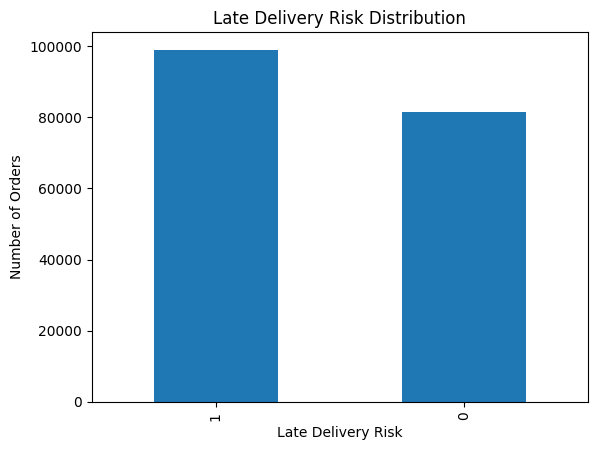

In [8]:
df["Late_delivery_risk"].value_counts().plot(kind="bar")

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
### Insight

# The number of late deliveries exceeds the number of on-time deliveries.

# This indicates that delivery delays represent a significant operational challenge and justify the need for predictive risk modeling.

In [9]:
df["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [10]:
pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"]
)

Late_delivery_risk,0,1
Shipping Mode,,
First Class,1301,26513
Same Day,5283,4454
Second Class,8229,26987
Standard Class,66729,41023


In [11]:
shipping_risk = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

shipping_risk

Late_delivery_risk,0,1
Shipping Mode,,
First Class,4.677501,95.322499
Same Day,54.256958,45.743042
Second Class,23.367219,76.632781
Standard Class,61.928317,38.071683


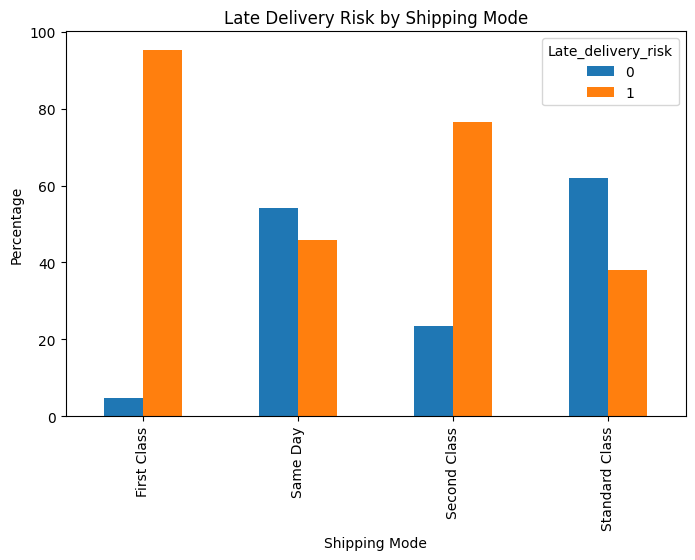

In [12]:
shipping_risk.plot(kind="bar", figsize=(8,5))

plt.title("Late Delivery Risk by Shipping Mode")
plt.ylabel("Percentage")
plt.xlabel("Shipping Mode")

plt.show()

In [13]:
### Business Insight

# Shipping mode influences delivery performance.

# Some shipping methods show a higher proportion of late deliveries than others, indicating potential operational bottlenecks and opportunities for process improvement.

In [14]:
df["Market"].value_counts()

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [15]:
market_risk = pd.crosstab(
    df["Market"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

market_risk

Late_delivery_risk,0,1
Market,,
Africa,45.410711,54.589289
Europe,44.792247,55.207753
LATAM,45.644842,54.355158
Pacific Asia,44.953951,55.046049
USCA,45.199426,54.800574


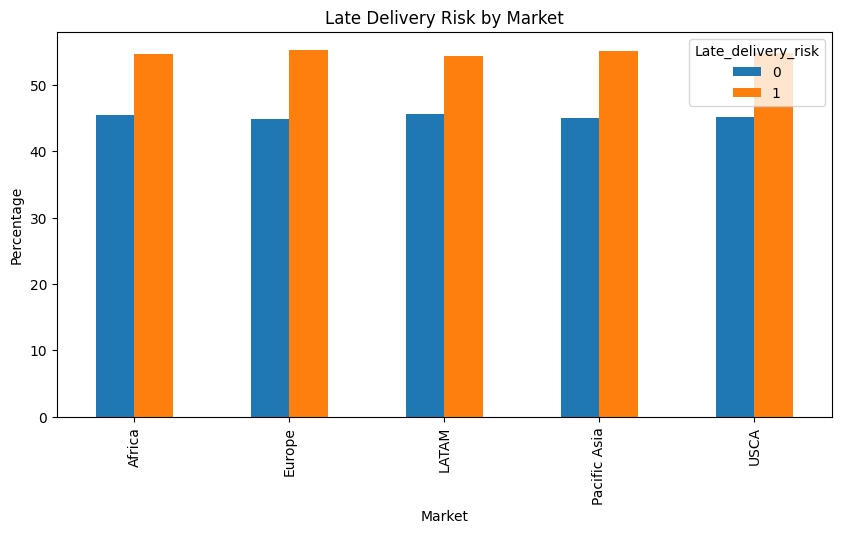

In [16]:
market_risk.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Late Delivery Risk by Market")
plt.ylabel("Percentage")
plt.xlabel("Market")

plt.show()

In [ ]:
### Business Insight

# Delivery performance varies across markets.

# Markets with higher late-delivery percentages should be prioritized for operational improvements and risk monitoring.

In [ ]:
#Which customer segments experience more late deliveries?

segment_risk = pd.crosstab(
    df["Customer Segment"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

segment_risk

Late_delivery_risk,0,1
Customer Segment,,
Consumer,45.191650,54.808350
Corporate,45.277337,54.722663
Home Office,44.929560,55.070440


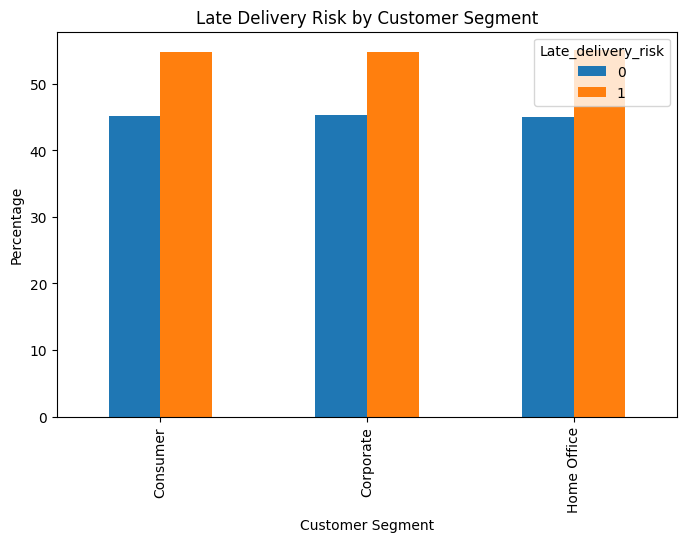

In [18]:
segment_risk.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Late Delivery Risk by Customer Segment")
plt.ylabel("Percentage")

plt.show()

In [19]:
#Region Risk Analysis

region_risk = pd.crosstab(
    df["Order Region"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

region_risk

Late_delivery_risk,0,1
Order Region,,
Canada,51.199166,48.800834
Caribbean,46.922337,53.077663
Central Africa,42.039356,57.960644
Central America,45.245404,54.754596
Central Asia,44.665461,55.334539
East Africa,44.060475,55.939525
East of USA,44.338395,55.661605
Eastern Asia,45.673077,54.326923
Eastern Europe,44.336735,55.663265


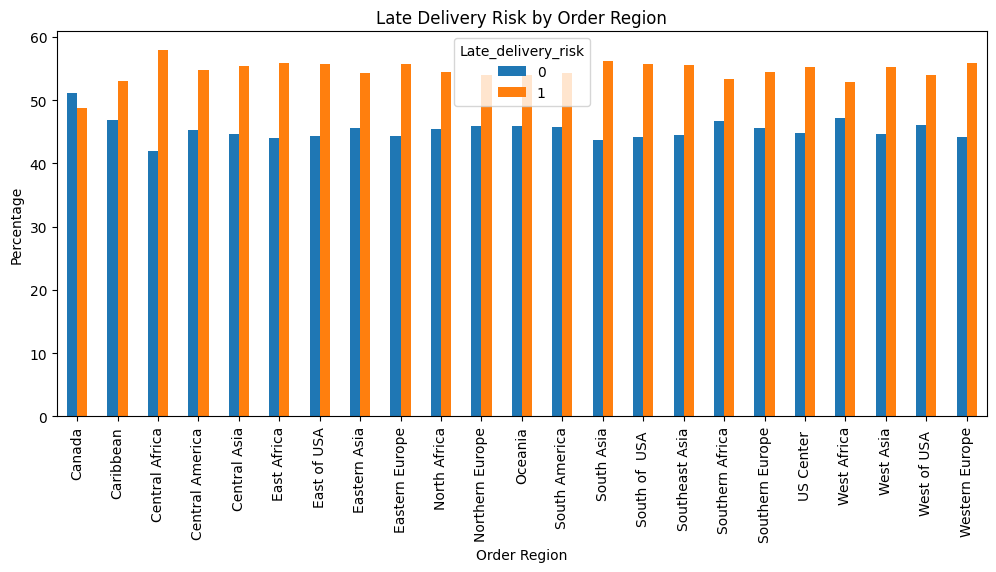

In [20]:
region_risk.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Late Delivery Risk by Order Region")
plt.ylabel("Percentage")

plt.show()